In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
print("PyTorch:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PyTorch: 2.14.0+cpu
Device: cpu


1. Tensors

In [3]:
# --- Example 1: creation ---
a = torch.tensor([[1, 2], [3, 4]])
b = torch.zeros(2, 3)
c = torch.ones(2, 3)
d = torch.rand(2, 3)          # uniform [0,1)
e = torch.randn(2, 3)         # standard normal
f = torch.arange(0, 10, 2)
g = torch.linspace(0, 1, 5)

print(a, a.dtype, a.shape, a.device)
print(d)
print(f, g)

tensor([[1, 2],
        [3, 4]]) torch.int64 torch.Size([2, 2]) cpu
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])
tensor([0, 2, 4, 6, 8]) tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


In [4]:
# --- Example 2: NumPy <-> tensor (shares memory with from_numpy!) ---
arr = np.array([1., 2., 3.])
t = torch.from_numpy(arr)
t += 1
print("NumPy array changed too:", arr)   # shared memory

back = t.numpy()
t2 = torch.tensor(arr)                   # .tensor() COPIES, no shared memory

NumPy array changed too: [2. 3. 4.]


indexing, reshaping, brodcasting

In [5]:
# --- Example 1: indexing & reshaping ---
x = torch.arange(24)
print(x[3:8])
print(x.flip(0)[:5])   # PyTorch doesn't support negative-step slicing like x[::-1] -- use .flip() instead

y = x.reshape(4, 6)
print(y)
print(y[1, :])          # row
print(y[:, 2])          # column
print(y.view(2, 12))    # view = reshape without copying (needs contiguous memory)

tensor([3, 4, 5, 6, 7])
tensor([23, 22, 21, 20, 19])
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])
tensor([ 6,  7,  8,  9, 10, 11])
tensor([ 2,  8, 14, 20])
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])


In [6]:
# --- Example 2: broadcasting ---
m = torch.ones(3, 4)
row = torch.tensor([1., 2., 3., 4.])
col = torch.tensor([[10.], [20.], [30.]])

print(m + row)     # (3,4) + (4,)   -> broadcasts across rows
print(m + col)     # (3,4) + (3,1)  -> broadcasts across columns

# matrix multiply
A = torch.randn(2, 3)
B = torch.randn(3, 4)
print((A @ B).shape)              # (2,4)
print(torch.matmul(A, B).shape)   # same thing

tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])
tensor([[11., 11., 11., 11.],
        [21., 21., 21., 21.],
        [31., 31., 31., 31.]])
torch.Size([2, 4])
torch.Size([2, 4])


GPU

In [7]:
x = torch.randn(3, 3)
if torch.cuda.is_available():
    x_gpu = x.to("cuda")
    print(x_gpu.device)
else:
    print("No GPU here — same code works with device='cuda' when you run on Colab/a GPU machine")

# Write device-agnostic code like this:
x = x.to(device)
print(x.device)

No GPU here — same code works with device='cuda' when you run on Colab/a GPU machine
cpu


2. Autograd

In [8]:
# --- Example 1: simple scalar function ---
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1          # y = (x+1)^2
y.backward()
print("dy/dx at x=3:", x.grad)     # should be 2x+2 = 8

dy/dx at x=3: tensor(8.)


In [9]:
# --- Example 2: gradient through several tensors (a mini "loss") ---
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
x_data = torch.tensor([1.0, 2.0, 3.0])
y_true = torch.tensor([3.0, 5.0, 7.0])   # y = 2x + 1 (true relationship)

y_pred = w * x_data + b
loss = ((y_pred - y_true)**2).mean()     # MSE
loss.backward()

print("loss:", loss.item())
print("dloss/dw:", w.grad.item())
print("dloss/db:", b.grad.item())

loss: 0.0
dloss/dw: 0.0
dloss/db: 0.0


In [10]:
# --- Example: grad accumulation trap ---
w = torch.tensor(2.0, requires_grad=True)
for step in range(3):
    loss = (w**2)
    loss.backward()
    print(f"step {step}: grad = {w.grad.item()}")   # keeps growing if not zeroed!
    w.grad.zero_()   # reset before next backward

step 0: grad = 4.0
step 1: grad = 4.0
step 2: grad = 4.0


In [11]:
# --- no_grad for inference / manual weight updates ---
w = torch.tensor(2.0, requires_grad=True)
loss = w**2
loss.backward()

with torch.no_grad():          # don't track this operation
    w -= 0.1 * w.grad          # manual gradient descent step
print(w)                        # w.requires_grad is still True, no error

tensor(1.6000, requires_grad=True)


In [12]:
# --- Example 1: custom class ---
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden)
        self.fc2 = nn.Linear(hidden, out_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = MLP(4, 16, 3)
print(model)

x = torch.randn(5, 4)   # batch of 5 samples, 4 features
out = model(x)          # calls forward() -- never call model.forward(x) directly
print(out.shape)        # (5, 3)

MLP(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=3, bias=True)
)
torch.Size([5, 3])


In [13]:
# --- Example 2: nn.Sequential (quick stack, same result style) ---
model2 = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 3),
)
print(model2)
print(model2(x).shape)

# Inspect parameters
for name, p in model.named_parameters():
    print(name, tuple(p.shape))
print("Total params:", sum(p.numel() for p in model.parameters()))

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=3, bias=True)
)
torch.Size([5, 3])
fc1.weight (16, 4)
fc1.bias (16,)
fc2.weight (3, 16)
fc2.bias (3,)
Total params: 131


In [14]:
print(nn.Linear(10, 5))       # fully connected
print(nn.Conv2d(3, 16, 3))    # conv layer (in_ch, out_ch, kernel)
print(nn.Dropout(0.3))        # regularization
print(nn.BatchNorm1d(16))     # normalization

x = torch.tensor([-2., -0.5, 0., 0.5, 2.])
print("ReLU   :", F.relu(x))
print("Sigmoid:", torch.sigmoid(x))
print("Tanh   :", torch.tanh(x))
print("Softmax:", F.softmax(torch.tensor([[1., 2., 3.]]), dim=1))   # for multi-class output

Linear(in_features=10, out_features=5, bias=True)
Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
Dropout(p=0.3, inplace=False)
BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
ReLU   : tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
Sigmoid: tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])
Tanh   : tensor([-0.9640, -0.4621,  0.0000,  0.4621,  0.9640])
Softmax: tensor([[0.0900, 0.2447, 0.6652]])


In [15]:
# --- Example 1: loss functions ---
mse = nn.MSELoss()
pred = torch.tensor([2.5, 0.0, 2.0])
true = torch.tensor([3.0, -0.5, 2.0])
print("MSE:", mse(pred, true).item())

bce = nn.BCEWithLogitsLoss()
logits = torch.tensor([2.0, -1.0, 0.5])      # raw scores, NOT probabilities
labels = torch.tensor([1., 0., 1.])
print("BCE:", bce(logits, labels).item())

ce = nn.CrossEntropyLoss()
logits3 = torch.tensor([[2.0, 0.5, 0.1], [0.1, 0.2, 3.0]])   # (batch, classes) raw scores
labels3 = torch.tensor([0, 2])                                 # class indices, not one-hot
print("CrossEntropy:", ce(logits3, labels3).item())

MSE: 0.1666666716337204
BCE: 0.3047555983066559
CrossEntropy: 0.21319009363651276


In [16]:
# --- Example 2: optimizers ---
model = nn.Linear(1, 1)
opt_sgd  = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
opt_adam = torch.optim.Adam(model.parameters(), lr=0.01)

print(opt_sgd)
print(opt_adam)

# One manual step to see the pattern used every training loop:
x = torch.tensor([[1.0]])
y = torch.tensor([[3.0]])
pred = model(x)
loss = mse(pred, y)

opt_adam.zero_grad()   # 1. clear old grads
loss.backward()        # 2. compute new grads
opt_adam.step()        # 3. update weights using those grads
print("loss:", loss.item())

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)
loss: 7.57768440246582


epoch   0  loss 0.7832
epoch  40  loss 0.3030
epoch  80  loss 0.2582
epoch 120  loss 0.2347
epoch 160  loss 0.1980


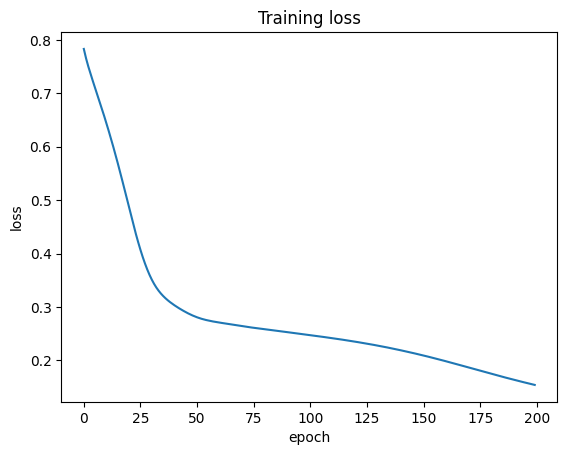

In [17]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.long)

model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

losses = []
for epoch in range(200):
    pred = model(X_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 40 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}")

plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Training loss"); plt.show()

Test accuracy: 0.9449999928474426


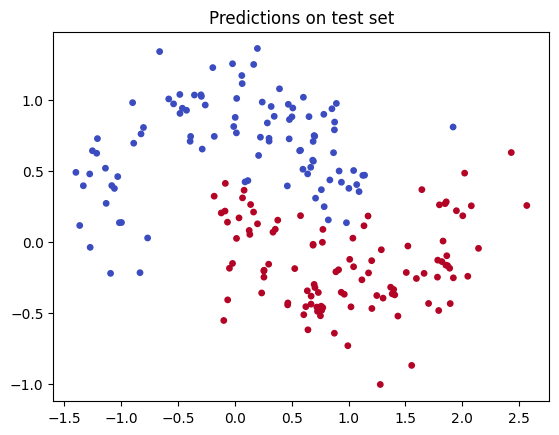

In [18]:
# --- Evaluation: switch to model.eval() + torch.no_grad() ---
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_preds = test_logits.argmax(dim=1)
    acc = (test_preds == y_test).float().mean()
print("Test accuracy:", acc.item())

plt.scatter(X_test[:,0], X_test[:,1], c=test_preds, cmap="coolwarm", s=15)
plt.title("Predictions on test set"); plt.show()

In [20]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

# --- Example 1: custom Dataset ---
class MoonsDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_ds = MoonsDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

xb, yb = next(iter(train_loader))
print("Batch shapes:", xb.shape, yb.shape)

Batch shapes: torch.Size([32, 2]) torch.Size([32])


In [21]:
# --- Example 2: TensorDataset (shortcut when data is already tensors) ---
train_ds2 = TensorDataset(X_train, y_train)
train_loader2 = DataLoader(train_ds2, batch_size=64, shuffle=True)

# Full mini-batch training loop (this is what real projects look like)
model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(5):
    epoch_loss = 0
    for xb, yb in train_loader2:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    print(f"epoch {epoch}: avg loss {epoch_loss/len(train_ds2):.4f}")

epoch 0: avg loss 0.6128
epoch 1: avg loss 0.4368
epoch 2: avg loss 0.3394
epoch 3: avg loss 0.3041
epoch 4: avg loss 0.2785


In [22]:
import os
os.makedirs("saved_pt", exist_ok=True)

# --- Save ---
torch.save(model.state_dict(), "saved_pt/moons_model.pt")
print("saved, size:", os.path.getsize("saved_pt/moons_model.pt"), "bytes")

# --- Load: must recreate the identical architecture first ---
loaded_model = nn.Sequential(nn.Linear(2, 16), nn.ReLU(), nn.Linear(16, 2))
loaded_model.load_state_dict(torch.load("saved_pt/moons_model.pt"))
loaded_model.eval()

with torch.no_grad():
    same = torch.allclose(model(X_test), loaded_model(X_test))
print("Loaded model gives identical output:", same)

saved, size: 2821 bytes
Loaded model gives identical output: True


In [23]:
# --- Example 1: shapes through a conv + pool, on a dummy image ---
x = torch.randn(1, 1, 8, 8)   # 1 image, 1 channel, 8x8 (same size as our digits dataset)

conv = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
pool = nn.MaxPool2d(kernel_size=2)

out = conv(x)
print("after conv :", out.shape)   # (1, 8, 8, 8) -- padding=1 keeps spatial size
out = pool(out)
print("after pool :", out.shape)   # (1, 8, 4, 4) -- pool halves H and W
print("flattened  :", out.flatten(1).shape)   # ready for a Linear layer

after conv : torch.Size([1, 8, 8, 8])
after pool : torch.Size([1, 8, 4, 4])
flattened  : torch.Size([1, 128])


In [24]:
# --- Example 2: a small CNN class ---
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool  = nn.MaxPool2d(2)
        self.fc1   = nn.Linear(32 * 2 * 2, 64)
        self.fc2   = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 8x8 -> 4x4
        x = self.pool(F.relu(self.conv2(x)))   # 4x4 -> 2x2
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

cnn = SimpleCNN()
print(cnn)
print(cnn(torch.randn(4, 1, 8, 8)).shape)   # (4, 10) -- 4 images, 10 class scores each

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=128, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
)
torch.Size([4, 10])


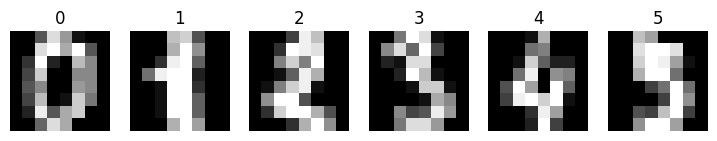

torch.Size([1437, 1, 8, 8]) torch.Size([1437])


In [25]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.images, digits.target       # X: (1797, 8, 8)

fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for i, ax in enumerate(axes):
    ax.imshow(X[i], cmap="gray"); ax.set_title(y[i]); ax.axis("off")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Reshape to (N, channels=1, H, W) and normalize to 0-1
X_train_t = torch.tensor(X_train / 16.0, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test / 16.0, dtype=torch.float32).unsqueeze(1)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t  = torch.tensor(y_test, dtype=torch.long)
print(X_train_t.shape, y_train_t.shape)

In [26]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

cnn = SimpleCNN().to(device)
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(10):
    cnn.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = cnn(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_loss += loss.item() * len(xb)
    if epoch % 2 == 0:
        print(f"epoch {epoch}: loss {total_loss/len(train_loader.dataset):.4f}")

cnn.eval()
with torch.no_grad():
    test_preds = cnn(X_test_t.to(device)).argmax(1).cpu()
acc = (test_preds == y_test_t).float().mean()
print("Test accuracy:", acc.item())

epoch 0: loss 2.2600
epoch 2: loss 0.8518
epoch 4: loss 0.2921
epoch 6: loss 0.1900
epoch 8: loss 0.1485
Test accuracy: 0.9472222328186035


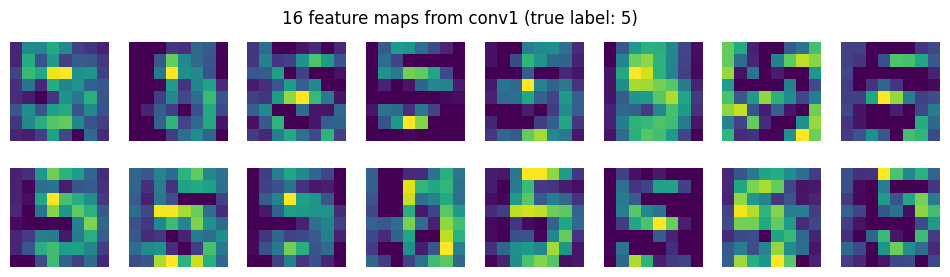

In [27]:
# Visualize what the first conv layer's filters respond to (feature maps) for one image
sample = X_test_t[0:1].to(device)
with torch.no_grad():
    fmap = F.relu(cnn.conv1(sample))[0].cpu()   # (16, 8, 8)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmap[i], cmap="viridis"); ax.axis("off")
plt.suptitle(f"16 feature maps from conv1 (true label: {y_test[0]})")
plt.show()

In [28]:
# --- Example 1: shapes through nn.RNN and nn.LSTM ---
x = torch.randn(4, 10, 3)   # batch=4, seq_len=10, input_size=3

rnn = nn.RNN(input_size=3, hidden_size=8, batch_first=True)
out, h_n = rnn(x)
print("RNN  out:", out.shape, "| final hidden:", h_n.shape)   # out: every timestep, h_n: last only

lstm = nn.LSTM(input_size=3, hidden_size=8, batch_first=True)
out, (h_n, c_n) = lstm(x)                     # LSTM also returns a cell state c_n
print("LSTM out:", out.shape, "| h_n:", h_n.shape, "| c_n:", c_n.shape)

# For classification/regression you usually use the LAST timestep's output:
last_step = out[:, -1, :]
print("last step:", last_step.shape)   # (4, 8) -> feed this into a Linear layer

RNN  out: torch.Size([4, 10, 8]) | final hidden: torch.Size([1, 4, 8])
LSTM out: torch.Size([4, 10, 8]) | h_n: torch.Size([1, 4, 8]) | c_n: torch.Size([1, 4, 8])
last step: torch.Size([4, 8])


In [29]:
def make_sequences(n, seq_len=15):
    X = torch.randn(n, seq_len, 1)
    y = (X.sum(dim=1).squeeze(1) > 0).long()   # label: 1 if sum > 0 else 0
    return X, y

X_seq_tr, y_seq_tr = make_sequences(2000)
X_seq_te, y_seq_te = make_sequences(400)

class SeqClassifier(nn.Module):
    def __init__(self, hidden=16):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden, batch_first=True)
        self.fc   = nn.Linear(hidden, 2)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        return self.fc(h_n[-1])       # h_n[-1] = last layer's final hidden state

seq_model = SeqClassifier()
opt = torch.optim.Adam(seq_model.parameters(), lr=0.01)
crit = nn.CrossEntropyLoss()
loader = DataLoader(TensorDataset(X_seq_tr, y_seq_tr), batch_size=64, shuffle=True)

for epoch in range(15):
    for xb, yb in loader:
        pred = seq_model(xb)
        loss = crit(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
    if epoch % 3 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}")

with torch.no_grad():
    acc = (seq_model(X_seq_te).argmax(1) == y_seq_te).float().mean()
print("Test accuracy:", acc.item())

epoch 0: loss 0.2096
epoch 3: loss 0.0955
epoch 6: loss 0.0443
epoch 9: loss 0.5193
epoch 12: loss 0.0217
Test accuracy: 0.9775000214576721


In [30]:
import torchvision.models as models

# weights=None here so this runs fully offline. On a normal machine with internet:
#   resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)   # downloads pretrained weights
resnet = models.resnet18(weights=None)
print(resnet.fc)   # the final classification layer -- this is what we replace

Linear(in_features=512, out_features=1000, bias=True)


In [31]:
# --- The transfer-learning pattern (this is the part to remember) ---

# 1) Freeze everything
for param in resnet.parameters():
    param.requires_grad = False

# 2) Replace the final layer for YOUR number of classes (say, 10)
num_classes = 10
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)   # new layer -> requires_grad=True by default

# 3) Only the new layer's parameters will be trained
trainable = [n for n, p in resnet.named_parameters() if p.requires_grad]
print("Trainable params:", trainable)

# 4) Optimizer only needs the trainable parameters
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)
print(optimizer)

Trainable params: ['fc.weight', 'fc.bias']
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [32]:
# --- Example 1: a transformer encoder block, shapes only ---
x = torch.randn(4, 10, 32)   # (batch, seq_len, embed_dim)

layer = nn.TransformerEncoderLayer(d_model=32, nhead=4, dim_feedforward=64, batch_first=True)
encoder = nn.TransformerEncoder(layer, num_layers=2)

out = encoder(x)
print("output:", out.shape)   # same shape as input -- transformer keeps seq_len, transforms each token's representation

output: torch.Size([4, 10, 32])


In [33]:
# --- Example 2: full toy model -- embedding + positional encoding + transformer + classifier ---
class TinyTransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=32, nhead=4, num_layers=2, num_classes=2, max_len=20):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, d_model)
        self.pos_embed = nn.Embedding(max_len, d_model)     # learned positional encoding
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=64, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):                       # x: (batch, seq_len) token IDs
        positions = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.embed(x) + self.pos_embed(positions)
        h = self.encoder(h)
        h = h.mean(dim=1)                         # pool over the sequence
        return self.fc(h)

toy = TinyTransformerClassifier(vocab_size=50, num_classes=2)
tokens = torch.randint(0, 50, (4, 12))            # 4 sequences, 12 tokens each
print(toy(tokens).shape)                          # (4, 2)

torch.Size([4, 2])


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1) Data (reuse the digits split from Section 1)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# 2) Model
class DigitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 8x8 -> 4x4
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 4x4 -> 2x2
            nn.Flatten(),
            nn.Linear(32*2*2, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 10),
        )
    def forward(self, x): return self.net(x)

model = DigitCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epoch  0: train_loss 2.2722  test_acc 0.4806
epoch  4: train_loss 0.4822  test_acc 0.9278
epoch  8: train_loss 0.2049  test_acc 0.9500
epoch 12: train_loss 0.1369  test_acc 0.9750
epoch 16: train_loss 0.1103  test_acc 0.9778


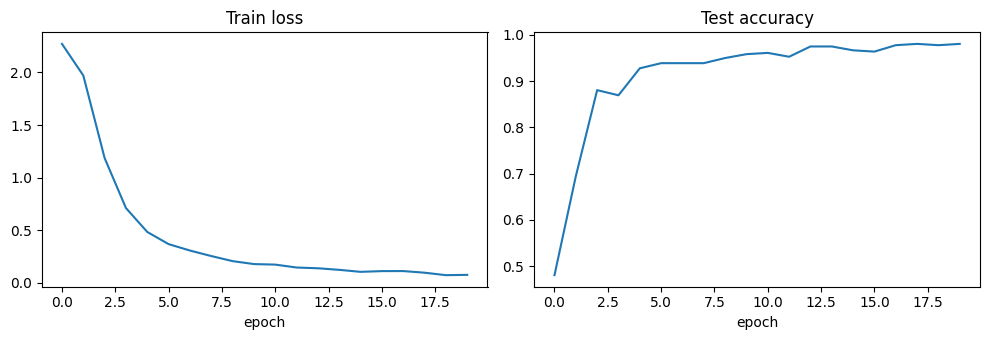

In [35]:
# 3) Train, tracking both train and test loss (like Part 1's learning-curve idea)
train_losses, test_accs = [], []
for epoch in range(20):
    model.train()
    running = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item() * len(xb)
    train_losses.append(running / len(train_loader.dataset))

    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            correct += (model(xb).argmax(1) == yb).sum().item()
    test_accs.append(correct / len(test_loader.dataset))

    if epoch % 4 == 0:
        print(f"epoch {epoch:2d}: train_loss {train_losses[-1]:.4f}  test_acc {test_accs[-1]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(train_losses); ax[0].set_title("Train loss"); ax[0].set_xlabel("epoch")
ax[1].plot(test_accs); ax[1].set_title("Test accuracy"); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.95      0.97      0.96        36
           5       1.00      1.00      1.00        37
           6       0.97      0.97      0.97        36
           7       1.00      0.97      0.99        36
           8       0.97      0.91      0.94        35
           9       1.00      1.00      1.00        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



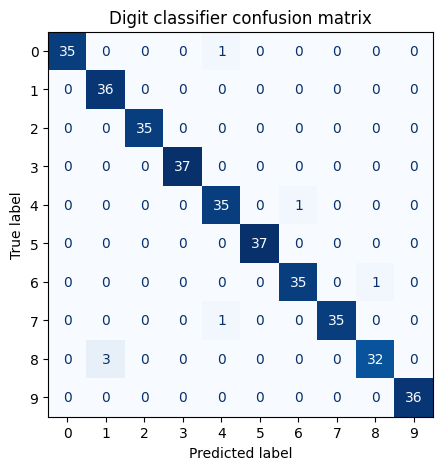

In [36]:
# 4) Full evaluation
model.eval()
with torch.no_grad():
    all_preds = model(X_test_t.to(device)).argmax(1).cpu().numpy()

print(classification_report(y_test, all_preds))
cm = confusion_matrix(y_test, all_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Digit classifier confusion matrix"); plt.show()

In [37]:
# 5) Save (weights + a metadata file, same pattern as the scikit-learn notebook)
import json, os
os.makedirs("saved_pt", exist_ok=True)
torch.save(model.state_dict(), "saved_pt/digit_cnn.pt")

meta = {
    "model": "DigitCNN",
    "torch_version": torch.__version__,
    "test_accuracy": round(test_accs[-1], 4),
    "classes": list(range(10)),
}
with open("saved_pt/digit_cnn_meta.json", "w") as f:
    json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))

{
  "model": "DigitCNN",
  "torch_version": "2.14.0+cpu",
  "test_accuracy": 0.9806,
  "classes": [
    0,
    1,
    2,
    3,
    4,
    5,
    6,
    7,
    8,
    9
  ]
}


In [ ]:
# 6) Reload and confirm identical predictions (same check as the scikit-learn notebook)
loaded = DigitCNN()
loaded.load_state_dict(torch.load("saved_pt/digit_cnn.pt", map_location="cpu"))
loaded.eval()

with torch.no_grad():
    same = torch.allclose(model.cpu()(X_test_t), loaded(X_test_t))
print("Loaded model gives identical predictions:", same)